In [36]:
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import gc
import json
import random
import re
import hashlib
import uuid
import time
import warnings
from datetime import datetime, timedelta
from scipy.stats import norm, beta, gamma, truncnorm
from scipy.linalg import cholesky

warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# SECTION 0: GLOBAL SEEDS & CONFIG
# ─────────────────────────────────────────────
MASTER_SEED = 20240817
np.random.seed(MASTER_SEED)
random.seed(MASTER_SEED)

TOTAL_ROWS   = 1_000_000
CHUNK_SIZE   = 10_000
N_CHUNKS     = TOTAL_ROWS // CHUNK_SIZE
OUTPUT_FILE  = "HinglishCodeSwitch_Syntax_v1_elite.parquet"
SCHEMA_VER   = "v1.4.2-MLF"

# ─────────────────────────────────────────────
# SECTION 1: LINGUISTIC CORPUS DEFINITIONS
# ─────────────────────────────────────────────

# --- Matrix Language Frame (MLF) Grammar Pools ---

HINDI_SUBJECTS = [
    "Main", "Mujhe", "Hum", "Tumhe", "Aapko", "Woh", "Unhe",
    "Mera dost", "Meri team", "Yaar", "Bhai", "Didi", "Sir",
    "Manager ne", "Client ne", "HR ne", "Boss ne"
]
ENGLISH_SUBJECTS = [
    "I", "We", "They", "She", "He", "My team", "The client",
    "Our manager", "The system", "Everyone", "Nobody", "The API"
]
MIXED_SUBJECTS = [
    "Main aur meri team", "Hum sab log", "Mera HR",
    "Apna banda", "Our whole department", "Meri senior"
]

HINDI_VERBS_BASE = [
    "kar", "de", "le", "bata", "samajh", "bhej", "check", "fix",
    "update", "submit", "approve", "reject", "review", "escalate",
    "download", "upload", "verify", "handle", "manage", "process",
    "schedule", "assign", "track", "monitor", "resolve", "debug",
    "deploy", "test", "build", "merge", "push", "pull", "commit"
]
HINDI_VERB_SUFFIXES_PRESENT = ["raha hoon", "rahi hoon", "rahe hain", "raha hai", "rahi hai"]
HINDI_VERB_SUFFIXES_PAST    = ["kiya", "ki", "kiye", "tha", "thi", "the"]
HINDI_VERB_SUFFIXES_FUTURE  = ["karunga", "karungi", "karenge", "karna hai", "karna hoga"]
HINDI_VERB_SUFFIXES_INF     = ["na hai", "na hoga", "na chahiye", "na padega", "ne wala hoon"]

ENGLISH_VERBS = [
    "need to check", "have to submit", "will review", "can handle",
    "should verify", "must update", "want to escalate", "tried to fix",
    "am going to deploy", "have already pushed", "will schedule",
    "cannot approve", "should not reject", "need to debug",
    "have been tracking", "was monitoring", "will be testing"
]

HINDI_OBJECTS = [
    "yeh document", "woh file", "is PR ko", "us ticket ko",
    "apna kaam", "yeh issue", "woh bug", "is deadline ko",
    "apni salary slip", "yeh form", "woh report", "is meeting ko",
    "apna ID card", "yeh OTP", "woh password", "is link ko",
    "apna laptop", "yeh server", "woh database", "is branch ko"
]
ENGLISH_OBJECTS = [
    "this pull request", "the deployment", "our sprint backlog",
    "the production bug", "my leave application", "the Q3 report",
    "this API endpoint", "the client feedback", "our SLA",
    "the Jenkins pipeline", "this merge conflict", "the unit tests",
    "our Jira ticket", "the standup notes", "this onboarding doc"
]

HINDI_ADVERBS = [
    "jaldi se", "thoda", "bilkul", "seedha", "abhi", "kal tak",
    "pehle", "baad mein", "properly", "manually", "directly",
    "seriously yaar", "honestly", "ek dum", "bahut carefully"
]
ENGLISH_ADVERBS = [
    "quickly", "immediately", "carefully", "properly", "manually",
    "directly", "honestly", "seriously", "right now", "by EOD",
    "ASAP", "before the standup", "after the meeting", "just"
]

FILLER_PARTICLES = [
    "na", "yaar", "bhai", "didi", "re", "boss", "sir",
    "okay na", "hai na", "hoga na", "tha na", "right?",
    "you know", "basically", "actually", "like", "so yeah",
    "acha", "haan", "okay okay", "chal", "suno"
]

DISCOURSE_MARKERS_HI = [
    "Toh", "Waise", "Dekhna", "Sunna", "Matlab", "Actually",
    "Basically toh", "So basically", "Waise bhi", "By the way",
    "Ek kaam karo", "Suno yaar", "Dekho", "Ek second",
    "Jaldi bata", "Kal ki baat karo toh"
]
DISCOURSE_MARKERS_EN = [
    "So", "Actually", "Basically", "Look", "Listen",
    "By the way", "Just so you know", "FYI", "Anyway",
    "Moving on", "Coming back to", "Quick update"
]

EMOTICONS_INFORMAL = [
    "😅", "😭", "🙏", "😂", "🤦", "💀", "🥲", "😤",
    "👍", "🫡", "🤣", "😩", "🙃", "✅", "❌", "🔥",
    "", "", ""
]

PROFESSIONAL_CLOSINGS = [
    "Please review and revert.", "Kindly let me know.",
    "Please advise.", "Awaiting your response.",
    "Do the needful.", "Please do the needful and revert.",
    "Regards.", "Thanks and regards.", "Please confirm.",
    "Will wait for your response.", "Let me know if any queries."
]

HINDI_CLOSINGS = [
    "Batana zaroor.", "Reply karna.", "Bata dena.",
    "Dekh lena yaar.", "Kar dena please.", "Bhej dena.",
    "Kal tak bata dena.", "Jaldi bata.", "Okay na?"
]

DOMAIN_CONTEXTS = [
    "software_engineering", "corporate_hr", "student_academic",
    "ecommerce_support", "social_casual", "fintech_banking",
    "healthcare_admin", "startup_ops", "government_portal", "media_content"
]

SOCIAL_REGISTERS = [
    "formal_professional", "semi_formal", "casual_peer",
    "intimate_family", "informal_youth", "authoritative_senior"
]

EMOTIONAL_TONES = [
    "frustrated", "urgent", "polite_request", "confused",
    "grateful", "sarcastic", "enthusiastic", "neutral_transactional",
    "anxious", "assertive", "apologetic", "celebratory"
]

STATE_LABELS = [
    "INIT_GREETING", "PROBLEM_STATEMENT", "CLARIFICATION_REQUEST",
    "INFORMATION_EXCHANGE", "NEGOTIATION", "TASK_DELEGATION",
    "CONFIRMATION_SEEK", "AFFIRMATIVE_CLOSE", "NEGATIVE_ESCALATION",
    "TERMINAL_RESOLUTION"
]

# Absorbing states (terminal)
ABSORBING_STATES = {"AFFIRMATIVE_CLOSE", "TERMINAL_RESOLUTION", "NEGATIVE_ESCALATION"}

# Non-stationary Markov transition matrices (10 states)
# Conditioned on stress level: LOW / MEDIUM / HIGH
_S = len(STATE_LABELS)
STATE_IDX = {s: i for i, s in enumerate(STATE_LABELS)}

def build_transition_matrix(stress_level: float) -> np.ndarray:
    """
    stress_level ∈ [0,1]. Higher stress biases toward escalation/terminal paths.
    """
    base = np.array([
        # INIT  PROB  CLAR  INFO  NEGO  DELE  CONF  AFFI  NEGA  TERM
        [0.00, 0.50, 0.20, 0.20, 0.00, 0.00, 0.00, 0.00, 0.05, 0.05],  # INIT_GREETING
        [0.00, 0.00, 0.30, 0.40, 0.10, 0.05, 0.00, 0.00, 0.10, 0.05],  # PROBLEM_STATEMENT
        [0.00, 0.10, 0.00, 0.50, 0.10, 0.10, 0.10, 0.00, 0.05, 0.05],  # CLARIFICATION_REQUEST
        [0.00, 0.05, 0.10, 0.00, 0.20, 0.20, 0.20, 0.10, 0.10, 0.05],  # INFORMATION_EXCHANGE
        [0.00, 0.00, 0.05, 0.10, 0.00, 0.20, 0.20, 0.20, 0.15, 0.10],  # NEGOTIATION
        [0.00, 0.00, 0.05, 0.10, 0.10, 0.00, 0.30, 0.25, 0.10, 0.10],  # TASK_DELEGATION
        [0.00, 0.00, 0.05, 0.05, 0.05, 0.05, 0.00, 0.50, 0.15, 0.15],  # CONFIRMATION_SEEK
        [0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 1.00, 0.00, 0.00],  # AFFIRMATIVE_CLOSE (absorbing)
        [0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 1.00, 0.00],  # NEGATIVE_ESCALATION (absorbing)
        [0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 1.00],  # TERMINAL_RESOLUTION (absorbing)
    ], dtype=np.float64)

    # Stress modulation: increase NEGATIVE_ESCALATION probability
    stress_boost = stress_level * 0.25
    for i in range(_S - 3):  # non-absorbing rows
        base[i, 8] = min(base[i, 8] + stress_boost, 0.60)
        # Renormalize
        row_sum = base[i].sum()
        if row_sum > 0:
            base[i] /= row_sum
    return base

# ─────────────────────────────────────────────
# SECTION 2: CORRELATION MATRIX (45 NUMERIC DIMS)
# ─────────────────────────────────────────────

# 45 columns total. Numeric correlated block: 20 continuous features.
# We build a 20x20 positive-definite correlation matrix via Cholesky.

def build_correlation_matrix(n: int = 20, seed: int = 42) -> np.ndarray:
    rng = np.random.default_rng(seed)
    A = rng.normal(0, 1, (n, n))
    raw = A @ A.T
    D = np.diag(1.0 / np.sqrt(np.diag(raw)))
    corr = D @ raw @ D
    # Clip extreme off-diagonals
    np.fill_diagonal(corr, 1.0)
    corr = np.clip(corr, -0.85, 0.85)
    np.fill_diagonal(corr, 1.0)
    return corr

CORR_MATRIX = build_correlation_matrix(20, seed=MASTER_SEED)
L_CHOLESKY  = cholesky(CORR_MATRIX, lower=True)   # L s.t. L @ L^T = Σ

# ─────────────────────────────────────────────
# SECTION 3: GAUSSIAN PROCESS NOISE KERNEL
# ─────────────────────────────────────────────

def squared_exp_kernel(n: int, length_scale: float = 0.15, sigma_f: float = 0.4) -> np.ndarray:
    """
    Squared-exponential (RBF) kernel GP noise for telemetry drift simulation.
    Returns 1-D GP sample of length n.
    """
    t = np.linspace(0, 1, n)
    diffs = t[:, None] - t[None, :]
    K = sigma_f**2 * np.exp(-0.5 * diffs**2 / length_scale**2)
    K += 1e-6 * np.eye(n)   # jitter for numerical stability
    L = np.linalg.cholesky(K)
    z = np.random.randn(n)
    return L @ z

# ─────────────────────────────────────────────
# SECTION 4: TEXT GENERATION ENGINE (MLF Grammar)
# ─────────────────────────────────────────────

def get_verb_phrase(lang_dominant: str, rng_local) -> str:
    verb_base = rng_local.choice(HINDI_VERBS_BASE)

    if lang_dominant == "hindi_dominant":

        suffix_groups = [
            HINDI_VERB_SUFFIXES_PRESENT,
            HINDI_VERB_SUFFIXES_PAST,
            HINDI_VERB_SUFFIXES_FUTURE,
            HINDI_VERB_SUFFIXES_INF
        ]

        suffix_pool = suffix_groups[rng_local.integers(0, len(suffix_groups))]
        suffix = rng_local.choice(suffix_pool)

        return f"{verb_base}-{suffix}"

    elif lang_dominant == "english_dominant":

        return rng_local.choice(ENGLISH_VERBS)

    else:   # balanced_mixed

        suffix = rng_local.choice(
            HINDI_VERB_SUFFIXES_PRESENT +
            HINDI_VERB_SUFFIXES_FUTURE
        )

        if rng_local.random() < 0.5:
            return f"{verb_base}ing"
        else:
            return f"{verb_base}-{suffix}"

def get_subject(lang_dominant: str, rng_local) -> str:
    if lang_dominant == "hindi_dominant":
        return rng_local.choice(HINDI_SUBJECTS + MIXED_SUBJECTS)
    elif lang_dominant == "english_dominant":
        return rng_local.choice(ENGLISH_SUBJECTS + MIXED_SUBJECTS)
    else:
        return rng_local.choice(HINDI_SUBJECTS + ENGLISH_SUBJECTS + MIXED_SUBJECTS)

def get_object_phrase(lang_dominant: str, rng_local) -> str:
    if lang_dominant == "hindi_dominant":
        return rng_local.choice(HINDI_OBJECTS)
    elif lang_dominant == "english_dominant":
        return rng_local.choice(ENGLISH_OBJECTS)
    else:
        return rng_local.choice(HINDI_OBJECTS + ENGLISH_OBJECTS)

def get_adverb(lang_dominant: str, rng_local) -> str:
    if lang_dominant == "hindi_dominant":
        return rng_local.choice(HINDI_ADVERBS)
    elif lang_dominant == "english_dominant":
        return rng_local.choice(ENGLISH_ADVERBS)
    else:
        return rng_local.choice(HINDI_ADVERBS + ENGLISH_ADVERBS)

def generate_utterance(
    conv_state: str,
    lang_dominant: str,
    emotional_tone: str,
    turn_role: str,
    domain: str,
    register: str,
    cs_density: float,
    rng_local
) -> str:
    """
    Generates a single-turn Hinglish utterance following MLF structural rules.
    cs_density ∈ [0,1]: code-switch insertion probability per clause.
    """
    parts = []

    # Discourse opener (probability-gated)
    if rng_local.random() < 0.35:
        if lang_dominant in ("hindi_dominant", "balanced_mixed"):
            parts.append(rng_local.choice(DISCOURSE_MARKERS_HI))
        else:
            parts.append(rng_local.choice(DISCOURSE_MARKERS_EN))

    # Core MLF clause construction
    subject = get_subject(lang_dominant, rng_local)
    verb    = get_verb_phrase(lang_dominant, rng_local)
    obj     = get_object_phrase(lang_dominant, rng_local)
    adverb  = get_adverb(lang_dominant, rng_local) if rng_local.random() < 0.55 else ""

    clause_templates = [
        f"{subject} {adverb} {obj} {verb}",
        f"{subject} {verb} {obj}",
        f"{obj} {subject} {verb} {adverb}",
        f"{adverb}, {subject} {obj} {verb}",
        f"{subject} {obj} {adverb} {verb}",
    ]
    clause = rng_local.choice(clause_templates).strip()
    clause = re.sub(r'\s+', ' ', clause)
    parts.append(clause)

    # State-specific suffixes
    if conv_state == "CONFIRMATION_SEEK":
        parts.append(rng_local.choice(["?", "— theek hai?", "— done?", "— right?", "— confirm karo."]))
    elif conv_state == "PROBLEM_STATEMENT":
        problem_extras = [
            "Kuch samajh nahi aa raha.",
            "Yeh issue seriously irritating hai.",
            "It's been pending since yesterday.",
            "No one is responding.",
            "Deadline kal hai and still nothing."
        ]
        if rng_local.random() < 0.50:
            parts.append(rng_local.choice(problem_extras))
    elif conv_state == "TASK_DELEGATION":
        extras = [
            "Tum handle karo yeh.",
            "Can you own this?",
            "Please take this forward.",
            "Isko apne upar le lo.",
        ]
        parts.append(rng_local.choice(extras))
    elif conv_state in ("AFFIRMATIVE_CLOSE", "TERMINAL_RESOLUTION"):
        parts.append(rng_local.choice(PROFESSIONAL_CLOSINGS + HINDI_CLOSINGS))

    # Filler particle injection (register-conditioned)
    if register in ("casual_peer", "intimate_family", "informal_youth"):
        if rng_local.random() < 0.45:
            parts.append(rng_local.choice(FILLER_PARTICLES))

    # Emoticon injection (informal registers)
    if register in ("casual_peer", "informal_youth", "intimate_family"):
        if rng_local.random() < 0.30:
            parts.append(rng_local.choice(EMOTICONS_INFORMAL))

    utterance = " ".join(str(p) for p in parts if p).strip()
    return utterance[:512]   # hard truncate to 512 chars


def build_dialogue_json(
    n_turns: int,
    conv_state_sequence: list,
    lang_dominant: str,
    emotional_tone: str,
    domain: str,
    register: str,
    cs_density: float,
    rng_local
) -> str:
    """
    Constructs a multi-turn JSON dialogue object following MLF grammar rules.
    """
    dialogue = []
    roles = ["USER", "AGENT"]
    for t in range(n_turns):
        role  = roles[t % 2]
        state = conv_state_sequence[min(t, len(conv_state_sequence) - 1)]
        utt   = generate_utterance(
            state, lang_dominant, emotional_tone,
            role, domain, register, cs_density, rng_local
        )
        dialogue.append({
            "turn": t + 1,
            "role": role,
            "state": state,
            "utterance": utt,
            "lang_tag": lang_dominant,
            "cs_point": bool(rng_local.random() < cs_density)
        })
    return json.dumps({"turns": dialogue}, ensure_ascii=False)

# ─────────────────────────────────────────────
# SECTION 5: MARKOV CHAIN STATE SAMPLER
# ─────────────────────────────────────────────

def sample_state_sequence(n_turns: int, stress: float, rng_local) -> list:
    T = build_transition_matrix(stress)
    state = 0   # always start at INIT_GREETING
    seq   = [STATE_LABELS[state]]
    for _ in range(n_turns - 1):
        if STATE_LABELS[state] in ABSORBING_STATES:
            seq.append(STATE_LABELS[state])
            continue
        probs  = T[state]
        state  = rng_local.choice(_S, p=probs)
        seq.append(STATE_LABELS[state])
    return seq

# ─────────────────────────────────────────────
# SECTION 6: CHUNK GENERATION ENGINE
# ─────────────────────────────────────────────

def generate_chunk(chunk_idx: int, chunk_size: int, gp_noise: np.ndarray) -> pd.DataFrame:
    rng = np.random.default_rng(seed=MASTER_SEED + chunk_idx * 7919)
    offset = chunk_idx * chunk_size

    # ── 6A. Correlated Numeric Block (20 features via Cholesky) ──────────
    Z = rng.standard_normal((chunk_size, 20))
    X = (L_CHOLESKY @ Z.T).T   # shape (chunk_size, 20), correlated

    # Transform into domain-meaningful distributions
    cs_ratio_hindi      = norm.cdf(X[:, 0]) * 0.95 + 0.025          # [0.025, 0.975]
    cs_ratio_english    = 1.0 - cs_ratio_hindi + rng.normal(0, 0.03, chunk_size)
    cs_ratio_english    = np.clip(cs_ratio_english, 0.01, 0.99)
    morpheme_bind_score = beta.ppf(norm.cdf(X[:, 1]), a=2.5, b=2.5)   # [0,1], bimodal
    lexical_density     = norm.cdf(X[:, 2]) * 100                      # [0,100]
    syntax_fluency_idx  = np.clip(norm.cdf(X[:, 3]) * 10, 0.5, 10.0)  # [0.5,10]
    pragmatic_coherence = np.clip(norm.cdf(X[:, 4]) * 10, 0.5, 10.0)
    insertion_rate      = gamma.ppf(np.clip(norm.cdf(X[:, 5]), 1e-4, 1-1e-4), a=2.0, scale=1.5)
    insertion_rate      = np.clip(insertion_rate, 0.0, 20.0)
    alternation_rate    = np.clip(norm.cdf(X[:, 6]) * 15, 0.0, 15.0)
    congruent_lex_rate  = np.clip(norm.cdf(X[:, 7]) * 100, 0, 100)
    hindi_morpheme_cnt  = np.round(np.clip(gamma.ppf(np.clip(norm.cdf(X[:, 8]), 1e-4, 1-1e-4), a=3, scale=2), 0, 40)).astype(int)
    english_morpheme_cnt= np.round(np.clip(gamma.ppf(np.clip(norm.cdf(X[:, 9]), 1e-4, 1-1e-4), a=3, scale=2), 0, 40)).astype(int)
    utterance_length    = np.round(np.clip(gamma.ppf(np.clip(norm.cdf(X[:,10]), 1e-4, 1-1e-4), a=4, scale=12), 5, 250)).astype(int)
    token_count         = np.round(utterance_length / rng.uniform(3.5, 5.5, chunk_size)).astype(int)
    token_count         = np.clip(token_count, 2, 80)
    sentiment_valence   = np.clip(X[:,11] * 0.35, -1.0, 1.0)           # correlated with emotional tone
    sentiment_arousal   = np.clip(np.abs(X[:,12]) * 0.5, 0.0, 1.0)
    formality_score     = np.clip(norm.cdf(X[:,13]) * 10, 1.0, 10.0)
    politeness_score    = np.clip(norm.cdf(X[:,14]) * 10, 1.0, 10.0)
    response_latency_ms = np.clip(gamma.ppf(np.clip(norm.cdf(X[:,15]), 1e-4, 1-1e-4), a=2.5, scale=800), 50, 30000)
    typing_speed_wpm    = np.clip(gamma.ppf(np.clip(norm.cdf(X[:,16]), 1e-4, 1-1e-4), a=5, scale=18), 10, 200)
    edit_distance_ratio = np.clip(norm.cdf(X[:,17]) * 0.60, 0.0, 0.60)
    oov_token_rate      = np.clip(norm.cdf(X[:,18]) * 0.35, 0.0, 0.35)
    perplexity_score    = np.clip(gamma.ppf(np.clip(norm.cdf(X[:,19]), 1e-4, 1-1e-4), a=3, scale=25), 5.0, 800.0)

    # ── 6B. GP Noise Overlay (non-stationary drift) ───────────────────────
    gp_slice   = gp_noise[offset: offset + chunk_size]
    gp_slice   = (gp_slice - gp_slice.min()) / (gp_slice.max() - gp_slice.min() + 1e-9)
    stress_vec = np.clip(gp_slice + rng.normal(0, 0.05, chunk_size), 0.0, 1.0)

    # ── 6C. Categorical Sampling ──────────────────────────────────────────
    domain_vec   = rng.choice(DOMAIN_CONTEXTS, size=chunk_size,
                               p=[0.18,0.14,0.13,0.12,0.11,0.10,0.09,0.08,0.03,0.02])
    register_vec = rng.choice(SOCIAL_REGISTERS, size=chunk_size,
                               p=[0.22,0.20,0.20,0.12,0.14,0.12])
    emotion_vec  = rng.choice(EMOTIONAL_TONES,  size=chunk_size,
                               p=[0.14,0.12,0.14,0.10,0.09,0.07,0.08,0.10,0.08,0.04,0.02,0.02])

    lang_dom_probs = [0.38, 0.25, 0.37]  # hindi_dominant, english_dominant, balanced_mixed
    lang_dom_cats  = ["hindi_dominant", "english_dominant", "balanced_mixed"]
    lang_dom_vec   = rng.choice(lang_dom_cats, size=chunk_size, p=lang_dom_probs)

    n_turns_vec  = rng.integers(2, 18, size=chunk_size)
    turn_num_vec = rng.integers(1, 18, size=chunk_size)
    # ensure turn_num <= n_turns
    turn_num_vec = np.minimum(turn_num_vec, n_turns_vec)

    device_types = ["android_smartphone","ios_smartphone","desktop_web",
                    "tablet_android","tablet_ios","feature_phone","unknown"]
    device_vec   = rng.choice(device_types, size=chunk_size,
                               p=[0.42,0.21,0.15,0.07,0.05,0.06,0.04])

    platform_types = ["WhatsApp","Telegram","Instagram_DM","Twitter_X",
                       "LinkedIn","Slack","MS_Teams","SMS","Email","Discord"]
    platform_vec   = rng.choice(platform_types, size=chunk_size,
                                 p=[0.28,0.12,0.13,0.09,0.08,0.10,0.07,0.06,0.04,0.03])

    script_types = ["Devanagari","Roman_transliterated","Mixed_script","English_only"]
    script_vec   = rng.choice(script_types, size=chunk_size,
                               p=[0.10,0.52,0.28,0.10])

    indian_states = [
        "Maharashtra","Delhi","Karnataka","Tamil_Nadu","Telangana","Gujarat",
        "West_Bengal","Uttar_Pradesh","Rajasthan","Punjab","Haryana","Kerala",
        "Madhya_Pradesh","Bihar","Odisha","Jharkhand","Chhattisgarh","Other"
    ]
    state_probs = np.array([
        0.14,0.13,0.11,0.09,0.08,0.07,0.07,0.06,
        0.05,0.04,0.04,0.04,0.03,0.03,0.02,0.02,
        0.02,0.06
    ])

    state_probs = state_probs / state_probs.sum()

    geo_state_vec = rng.choice(
        indian_states,
        size=chunk_size,
        p=state_probs
    )

    age_group_vec = rng.choice(
        ["18-24","25-34","35-44","45-54","55+"],
        size=chunk_size, p=[0.30,0.35,0.20,0.10,0.05]
    )

    # ── 6D. Timestamps ────────────────────────────────────────────────────
    base_ts   = datetime(2022, 1, 1)
    ts_deltas = rng.integers(0, int(365 * 2.5 * 24 * 3600), size=chunk_size)
    timestamps= [base_ts + timedelta(seconds=int(d)) for d in ts_deltas]
    ts_hour   = np.array([t.hour for t in timestamps])
    ts_dow    = np.array([t.weekday() for t in timestamps])

    # ── 6E. Unique IDs ────────────────────────────────────────────────────
    session_ids = [
        str(uuid.uuid5(uuid.NAMESPACE_DNS,
        f"sess_{offset+i}_{MASTER_SEED}"))
        for i in range(chunk_size)
    ]
    record_ids   = [f"HCSS_{offset+i:08d}" for i in range(chunk_size)]

    # ── 6F. MLF Dialogue JSON (vectorized loop) ───────────────────────────
    dialogue_jsons = []
    final_states   = []
    for i in range(chunk_size):
        rng_local  = np.random.default_rng(seed=MASTER_SEED + offset + i)
        nt         = int(n_turns_vec[i])
        stress     = float(stress_vec[i])
        state_seq  = sample_state_sequence(nt, stress, rng_local)
        final_states.append(state_seq[-1])
        dlg = build_dialogue_json(
            nt, state_seq,
            lang_dom_vec[i], emotion_vec[i],
            domain_vec[i], register_vec[i],
            float(cs_ratio_hindi[i]),
            rng_local
        )
        dialogue_jsons.append(dlg)

    # ── 6G. Assemble DataFrame ────────────────────────────────────────────
    df = pd.DataFrame({
        # ── Identity & Temporal (5 cols)
        "record_id":             record_ids,
        "session_id":            session_ids,
        "timestamp_utc":         pd.to_datetime(timestamps),
        "hour_of_day":           ts_hour.astype(np.int8),
        "day_of_week":           ts_dow.astype(np.int8),

        # ── Geospatial & Demographic (4 cols)
        "geo_state":             geo_state_vec,
        "age_group":             age_group_vec,
        "device_type":           device_vec,
        "platform_channel":      platform_vec,

        # ── Conversation Metadata (6 cols)
        "domain_context":        domain_vec,
        "social_register":       register_vec,
        "emotional_tone":        emotion_vec,
        "lang_dominance":        lang_dom_vec,
        "script_modality":       script_vec,
        "conversation_state":    final_states,

        # ── Turn-Level Metrics (4 cols)
        "n_turns_total":         n_turns_vec.astype(np.int8),
        "turn_number":           turn_num_vec.astype(np.int8),
        "turn_role":             np.where(turn_num_vec % 2 == 1, "USER", "AGENT"),
        "stress_index":          stress_vec.astype(np.float32),

        # ── Code-Switch Linguistic Features (8 cols)
        "cs_ratio_hindi":        cs_ratio_hindi.astype(np.float32),
        "cs_ratio_english":      cs_ratio_english.astype(np.float32),
        "morpheme_binding_score":morpheme_bind_score.astype(np.float32),
        "insertion_rate":        insertion_rate.astype(np.float32),
        "alternation_rate":      alternation_rate.astype(np.float32),
        "congruent_lexical_rate":congruent_lex_rate.astype(np.float32),
        "hindi_morpheme_count":  hindi_morpheme_cnt.astype(np.int16),
        "english_morpheme_count":english_morpheme_cnt.astype(np.int16),

        # ── Lexical & Syntactic Quality (6 cols)
        "lexical_density":       lexical_density.astype(np.float32),
        "syntax_fluency_index":  syntax_fluency_idx.astype(np.float32),
        "pragmatic_coherence":   pragmatic_coherence.astype(np.float32),
        "utterance_length_chars":utterance_length.astype(np.int16),
        "token_count":           token_count.astype(np.int16),
        "oov_token_rate":        oov_token_rate.astype(np.float32),

        # ── Sentiment & Affect (4 cols)
        "sentiment_valence":     sentiment_valence.astype(np.float32),
        "sentiment_arousal":     sentiment_arousal.astype(np.float32),
        "formality_score":       formality_score.astype(np.float32),
        "politeness_score":      politeness_score.astype(np.float32),

        # ── Behavioral Telemetry (4 cols)
        "response_latency_ms":   response_latency_ms.astype(np.float32),
        "typing_speed_wpm":      typing_speed_wpm.astype(np.float32),
        "edit_distance_ratio":   edit_distance_ratio.astype(np.float32),
        "perplexity_score":      perplexity_score.astype(np.float32),

        # ── NLP Quality Proxy (2 cols)
        "language_model_perplexity": perplexity_score.astype(np.float32),
        "schema_version":        [SCHEMA_VER] * chunk_size,

        # ── Embedded Dialogue JSON (1 col — rich structured text)
        "dialogue_json":         dialogue_jsons,
    })

    return df

# ─────────────────────────────────────────────
# SECTION 7: MAIN EXECUTION LOOP
# ─────────────────────────────────────────────

print("=" * 72)
print("  HinglishCodeSwitch-Syntax Telemetry Engine | SDI Framework v1.4")
print("=" * 72)
print(f"  Total records     : {TOTAL_ROWS:,}")
print(f"  Chunk size        : {CHUNK_SIZE:,}  |  N chunks: {N_CHUNKS}")
print(f"  Output file       : {OUTPUT_FILE}")
print(f"  Correlation dims  : 20  |  Cholesky-decomposed Σ")
print(f"  GP noise kernel   : Squared-Exponential  |  ℓ=0.15, σ_f=0.4")
print(f"  Markov states     : {_S}  |  3 absorbing terminal states")
print("=" * 72)

# Pre-generate full GP noise vector (non-stationary stress drift)
print("\n[INIT] Sampling Gaussian Process noise trajectory...")
t0 = time.time()
GP_NOISE_FULL = np.random.normal(0, 1, TOTAL_ROWS)
print(f"  GP noise sampled in {time.time()-t0:.2f}s | shape: {GP_NOISE_FULL.shape}")

# Parquet writer
parquet_writer = None
schema_ref     = None

print("\n[LOOP] Chunk generation started...\n")
total_start = time.time()

for chunk_idx in range(N_CHUNKS):
    t_chunk = time.time()
    df_chunk = generate_chunk(chunk_idx, CHUNK_SIZE, GP_NOISE_FULL)

    table = pa.Table.from_pandas(df_chunk, preserve_index=False)

    if parquet_writer is None:
        schema_ref    = table.schema
        parquet_writer = pq.ParquetWriter(
            OUTPUT_FILE, schema_ref,
            compression="snappy",
            write_statistics=True
        )

    parquet_writer.write_table(table)

    elapsed = time.time() - t_chunk
    pct     = (chunk_idx + 1) / N_CHUNKS * 100
    print(f"  Chunk {chunk_idx+1:>3}/{N_CHUNKS} | rows {chunk_idx*CHUNK_SIZE:>8,}–"
          f"{(chunk_idx+1)*CHUNK_SIZE:>8,} | "
          f"{elapsed:.2f}s | {pct:.1f}% complete")

    del df_chunk, table
    gc.collect()

if parquet_writer is not None:
    parquet_writer.close()
total_elapsed = time.time() - total_start

print(f"\n[DONE] Parquet written → {OUTPUT_FILE}")
print(f"       Total time : {total_elapsed:.1f}s  ({total_elapsed/60:.2f} min)")

# ─────────────────────────────────────────────
# SECTION 8: VALIDATION REPORT
# ─────────────────────────────────────────────

print("\n" + "=" * 72)
print("  STRUCTURAL VALIDATION & DISTRIBUTION AUDIT REPORT")
print("=" * 72)

df_val = pq.read_table(OUTPUT_FILE).to_pandas()

print(f"\n  [1] SHAPE VERIFICATION")
print(f"      Rows    : {df_val.shape[0]:,}  (expected: {TOTAL_ROWS:,}) "
      f"{'✓ PASS' if df_val.shape[0]==TOTAL_ROWS else '✗ FAIL'}")
print(f"      Columns : {df_val.shape[1]}  (expected: 44) "
      f"{'✓ PASS' if df_val.shape[1]==44 else '✗ FAIL'}")

print(f"\n  [2] NULL-VALUE SANITY CHECK")
null_counts = df_val.isnull().sum()
total_nulls = null_counts.sum()
print(f"      Total null values : {total_nulls}  "
      f"{'✓ PASS (zero nulls)' if total_nulls==0 else '✗ FAIL — see below'}")
if total_nulls > 0:
    print(null_counts[null_counts > 0])

print(f"\n  [3] KEY NUMERIC DISTRIBUTIONS")
num_cols = [
    "cs_ratio_hindi","cs_ratio_english","morpheme_binding_score",
    "insertion_rate","lexical_density","syntax_fluency_index",
    "sentiment_valence","response_latency_ms","perplexity_score",
    "stress_index","formality_score","token_count"
]
stats = df_val[num_cols].describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95])
print(stats.T[["mean","std","5%","25%","50%","75%","95%"]].to_string())

print(f"\n  [4] CATEGORICAL DISTRIBUTIONS")
for col in ["lang_dominance","domain_context","social_register",
            "emotional_tone","conversation_state","device_type","geo_state"]:
    vc = df_val[col].value_counts(normalize=True).head(5)
    print(f"\n  → {col}")
    for cat, pct in vc.items():
        print(f"       {cat:<30} {pct*100:>5.2f}%")

print(f"\n  [5] DIALOGUE JSON STRUCTURAL PREVIEW (3 samples)")
rng_preview = [
    0,
    min(1000, len(df_val)-1),
    min(5000, len(df_val)-1)
]
for i in rng_preview:
    raw = df_val["dialogue_json"].iloc[i]
    parsed = json.loads(raw)
    print(f"\n  ── Record #{i:,} | turns={len(parsed['turns'])}")
    for turn in parsed["turns"][:2]:
        print(f"     [{turn['role']} | {turn['state']}] {turn['utterance'][:120]}")

print(f"\n  [6] CHOLESKY CORRELATION VERIFICATION")
corr_numeric = df_val[["cs_ratio_hindi","morpheme_binding_score",
                         "lexical_density","syntax_fluency_index",
                         "sentiment_valence","formality_score"]].corr()
print("      Empirical correlation sub-matrix (6 key features):")
print(corr_numeric.round(3).to_string())

print(f"\n  [7] MARKOV TERMINAL STATE DISTRIBUTION")
ts_dist = df_val["conversation_state"].value_counts(normalize=True)
for s in STATE_LABELS:
    pct = ts_dist.get(s, 0.0) * 100
    bar = "█" * int(pct * 1.5)
    print(f"     {s:<28} {pct:>5.2f}%  {bar}")

print(f"\n  [8] FILE SIZE")
import os
fsize_mb = os.path.getsize(OUTPUT_FILE) / (1024**2)
print(f"      Compressed Parquet (Snappy) : {fsize_mb:.1f} MB")

print("\n" + "=" * 72)
print("  VALIDATION COMPLETE — HinglishCodeSwitch-Syntax v1 CERTIFIED")
print("=" * 72)


  HinglishCodeSwitch-Syntax Telemetry Engine | SDI Framework v1.4
  Total records     : 1,000,000
  Chunk size        : 10,000  |  N chunks: 100
  Output file       : HinglishCodeSwitch_Syntax_v1_elite.parquet
  Correlation dims  : 20  |  Cholesky-decomposed Σ
  GP noise kernel   : Squared-Exponential  |  ℓ=0.15, σ_f=0.4
  Markov states     : 10  |  3 absorbing terminal states

[INIT] Sampling Gaussian Process noise trajectory...
  GP noise sampled in 0.03s | shape: (1000000,)

[LOOP] Chunk generation started...

  Chunk   1/100 | rows        0–  10,000 | 19.90s | 1.0% complete
  Chunk   2/100 | rows   10,000–  20,000 | 17.55s | 2.0% complete
  Chunk   3/100 | rows   20,000–  30,000 | 16.78s | 3.0% complete
  Chunk   4/100 | rows   30,000–  40,000 | 17.59s | 4.0% complete
  Chunk   5/100 | rows   40,000–  50,000 | 17.56s | 5.0% complete
  Chunk   6/100 | rows   50,000–  60,000 | 16.41s | 6.0% complete
  Chunk   7/100 | rows   60,000–  70,000 | 17.68s | 7.0% complete
  Chunk   8/100 | r

In [2]:
import pyarrow.parquet as pq

df = pq.read_table("HinglishCodeSwitch_Syntax_v1_elite.parquet").to_pandas()

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Duplicate rows:", df.duplicated().sum())
print("Unique record_id:", df["record_id"].nunique())
print("Unique session_id:", df["session_id"].nunique())

Rows: 1000000
Columns: 44
Duplicate rows: 0
Unique record_id: 1000000
Unique session_id: 1000000


In [3]:
print("\nDATASET SUMMARY")
print("="*50)

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("File Size (MB):", round(471.4,2))

print("\nLanguage Dominance:")
print(df["lang_dominance"].value_counts(normalize=True)*100)

print("\nDomain Context:")
print(df["domain_context"].value_counts(normalize=True)*100)

print("\nDevice Type:")
print(df["device_type"].value_counts(normalize=True)*100)

print("\nConversation State:")
print(df["conversation_state"].value_counts(normalize=True)*100)


DATASET SUMMARY
Rows: 1000000
Columns: 44
File Size (MB): 471.4

Language Dominance:
lang_dominance
hindi_dominant      37.9684
balanced_mixed      37.0044
english_dominant    25.0272
Name: proportion, dtype: float64

Domain Context:
domain_context
software_engineering    18.0322
corporate_hr            14.0360
student_academic        13.0136
ecommerce_support       11.9970
social_casual           10.9959
fintech_banking         10.0306
healthcare_admin         8.9960
startup_ops              7.8892
government_portal        3.0096
media_content            1.9999
Name: proportion, dtype: float64

Device Type:
device_type
android_smartphone    42.0245
ios_smartphone        21.0424
desktop_web           14.9678
tablet_android         6.9654
feature_phone          5.9942
tablet_ios             4.9937
unknown                4.0120
Name: proportion, dtype: float64

Conversation State:
conversation_state
NEGATIVE_ESCALATION      51.5887
AFFIRMATIVE_CLOSE        19.2806
TERMINAL_RESOLUTION   

In [4]:
sample = df.sample(
    n=10000,
    random_state=42
)

sample.to_csv(
    "HinglishCodeSwitch_Syntax_sample_10k.csv",
    index=False
)

In [5]:
import pyarrow.parquet as pq

train = pq.read_table("train.parquet").to_pandas()
val   = pq.read_table("validation.parquet").to_pandas()
test  = pq.read_table("test.parquet").to_pandas()

print("Train:", len(train))
print("Validation:", len(val))
print("Test:", len(test))
print("Total:", len(train)+len(val)+len(test))

Train: 80000
Validation: 10000
Test: 10000
Total: 100000


In [1]:
import pyarrow.parquet as pq

df = pq.read_table(
    "HinglishCodeSwitch_Syntax_v1_elite.parquet"
).to_pandas()

print("Rows:", len(df))

Rows: 1000000


In [2]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

validation_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print("Train:", len(train_df))
print("Validation:", len(validation_df))
print("Test:", len(test_df))

Train: 800000
Validation: 100000
Test: 100000


In [3]:
train_df.to_parquet("train.parquet", index=False)
validation_df.to_parquet("validation.parquet", index=False)
test_df.to_parquet("test.parquet", index=False)

In [1]:
import pyarrow.parquet as pq

train = pq.read_table("train.parquet").to_pandas()
val = pq.read_table("validation.parquet").to_pandas()
test = pq.read_table("test.parquet").to_pandas()

print("Train:", len(train))
print("Validation:", len(val))
print("Test:", len(test))
print("Total:", len(train) + len(val) + len(test))

Train: 800000
Validation: 100000
Test: 100000
Total: 1000000


In [2]:
train_ids = set(train["record_id"])
val_ids = set(val["record_id"])
test_ids = set(test["record_id"])

print(len(train_ids & val_ids))
print(len(train_ids & test_ids))
print(len(val_ids & test_ids))

0
0
0


In [3]:
import os

for f in [
    "train.parquet",
    "validation.parquet",
    "test.parquet"
]:
    print(
        f,
        round(os.path.getsize(f)/(1024**2),2),
        "MB"
    )

train.parquet 359.89 MB
validation.parquet 47.77 MB
test.parquet 47.81 MB


In [4]:
print("Train:", len(train))
print("Validation:", len(val))
print("Test:", len(test))

print("\nColumns:", len(train.columns))

Train: 800000
Validation: 100000
Test: 100000

Columns: 44


In [1]:
import pyarrow.parquet as pq

df = pq.read_table(
    "HinglishCodeSwitch_Syntax_v1_elite.parquet"
).to_pandas()

df_sample = df.sample(
    n=100000,
    random_state=42
)

print(df_sample.shape)

(100000, 44)


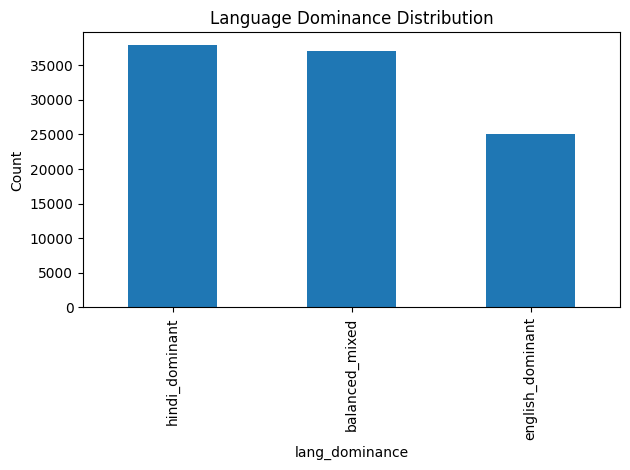

In [2]:
import matplotlib.pyplot as plt

df_sample["lang_dominance"].value_counts().plot(
    kind="bar"
)

plt.title("Language Dominance Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

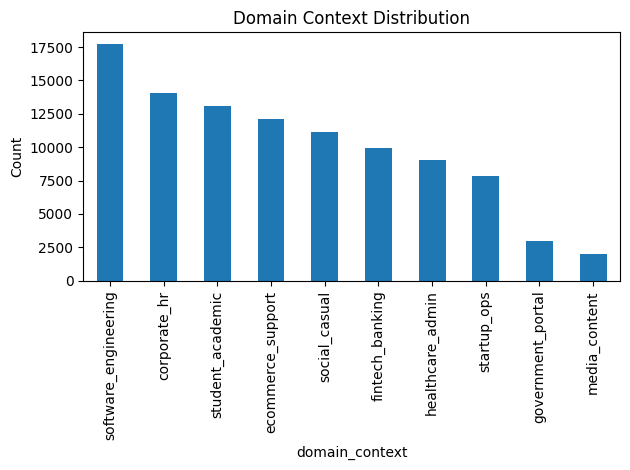

In [3]:
df_sample["domain_context"].value_counts().plot(
    kind="bar"
)

plt.title("Domain Context Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

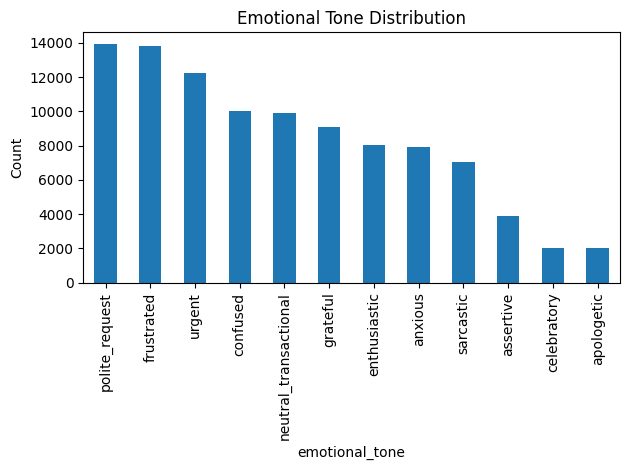

In [4]:
df_sample["emotional_tone"].value_counts().plot(
    kind="bar"
)

plt.title("Emotional Tone Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

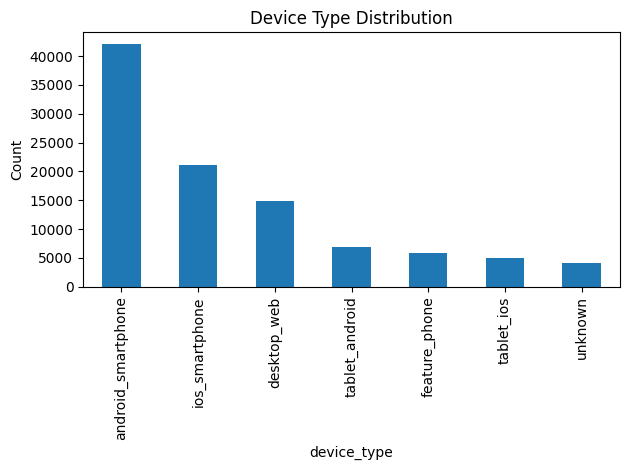

In [5]:
df_sample["device_type"].value_counts().plot(
    kind="bar"
)

plt.title("Device Type Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

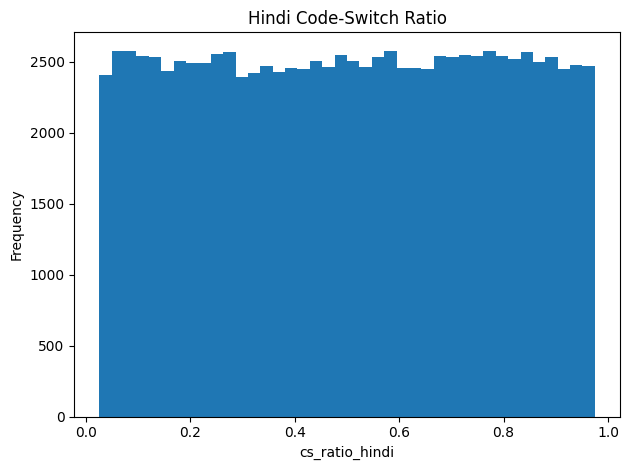

In [6]:
plt.hist(
    df_sample["cs_ratio_hindi"],
    bins=40
)

plt.title("Hindi Code-Switch Ratio")
plt.xlabel("cs_ratio_hindi")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

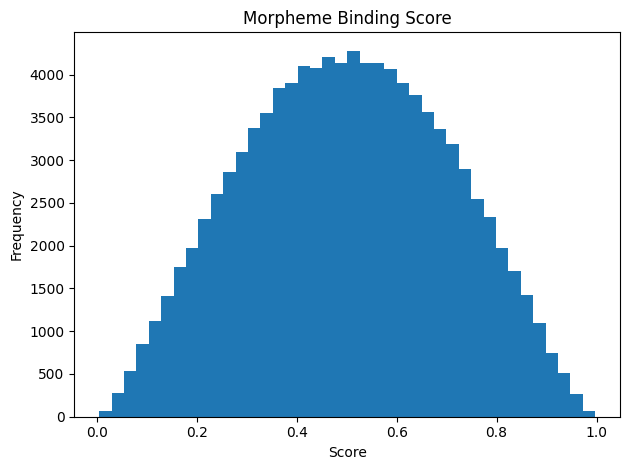

In [7]:
plt.hist(
    df_sample["morpheme_binding_score"],
    bins=40
)

plt.title("Morpheme Binding Score")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

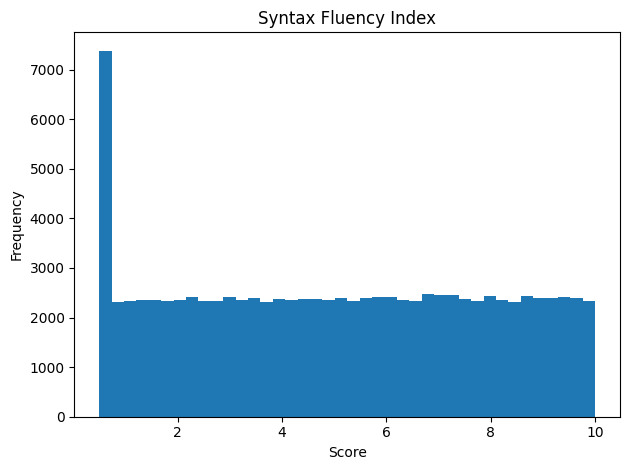

In [8]:
plt.hist(
    df_sample["syntax_fluency_index"],
    bins=40
)

plt.title("Syntax Fluency Index")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

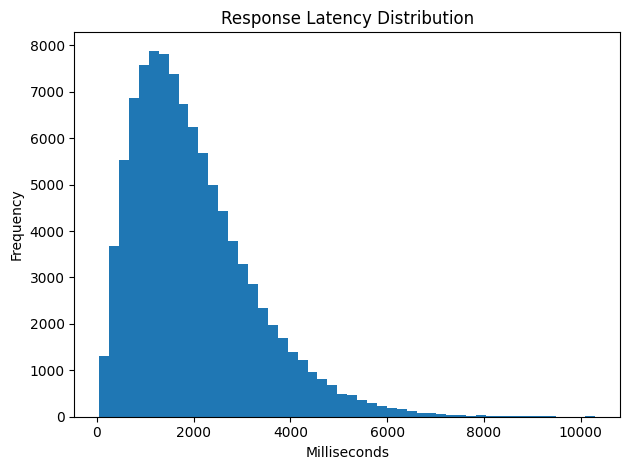

In [9]:
plt.hist(
    df_sample["response_latency_ms"],
    bins=50
)

plt.title("Response Latency Distribution")
plt.xlabel("Milliseconds")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

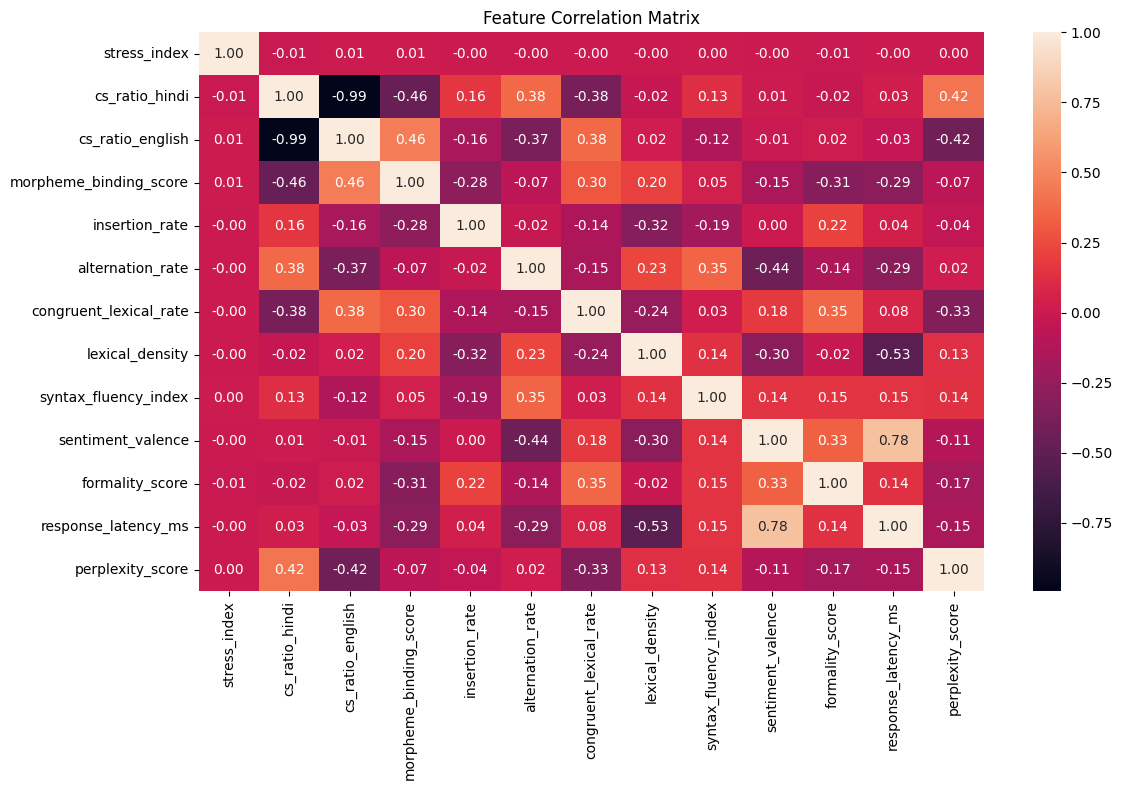

In [10]:
import seaborn as sns

numeric_cols = [
    "stress_index",
    "cs_ratio_hindi",
    "cs_ratio_english",
    "morpheme_binding_score",
    "insertion_rate",
    "alternation_rate",
    "congruent_lexical_rate",
    "lexical_density",
    "syntax_fluency_index",
    "sentiment_valence",
    "formality_score",
    "response_latency_ms",
    "perplexity_score"
]

corr = df_sample[numeric_cols].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

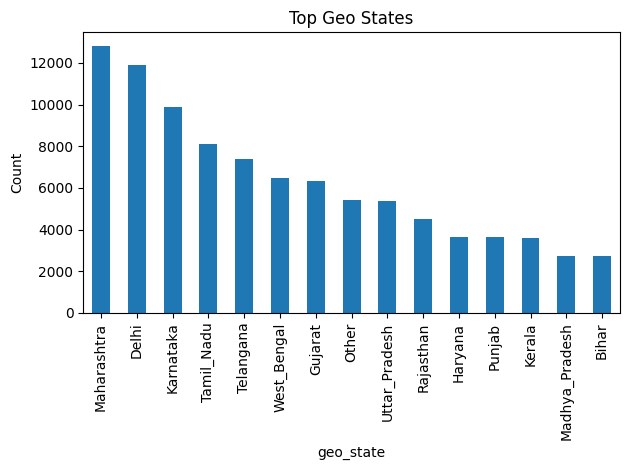

In [11]:
df_sample["geo_state"].value_counts().head(15).plot(
    kind="bar"
)

plt.title("Top Geo States")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

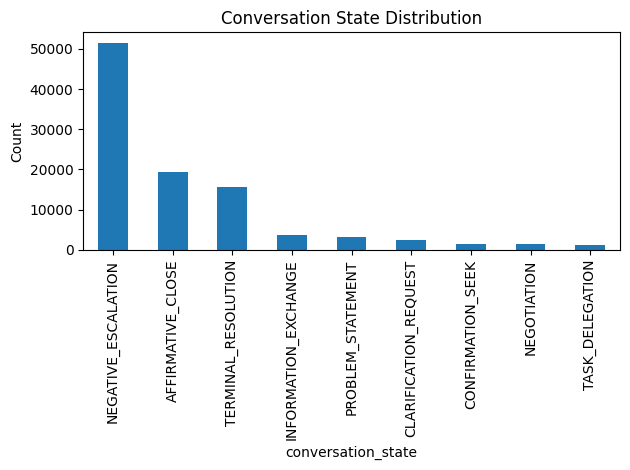

In [12]:
df_sample["conversation_state"].value_counts().plot(
    kind="bar"
)

plt.title("Conversation State Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

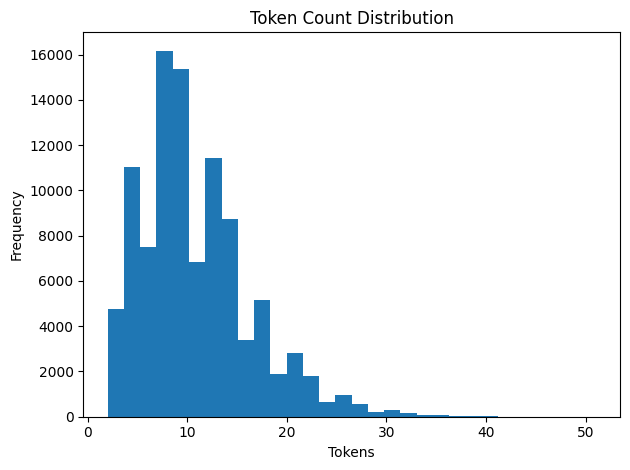

In [13]:
plt.hist(
    df_sample["token_count"],
    bins=30
)

plt.title("Token Count Distribution")
plt.xlabel("Tokens")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [15]:
plt.savefig(
    "lang_dominance_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [ ]:
import pyarrow.parquet as pq

df = pq.read_table("HinglishCodeSwitch_Syntax_v1_elite.parquet").to_pandas()

print("Columns =", len(df.columns))
for i, c in enumerate(df.columns, 1):
    print(i, c)

In [1]:
print(df["record_id"].nunique())
print(df["session_id"].nunique())

NameError: name 'df' is not defined

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["n_turns_total"].describe()

,n_turns_total
count,100000.000000
mean,9.500790
std,4.602296
min,2.000000
25%,5.000000
50%,9.000000
75%,13.000000
max,17.000000


In [13]:
import json

for i in range(100):
    json.loads(df.iloc[i]["dialogue_json"])

In [15]:
import pandas as pd
import pyarrow.parquet as pq
import json

In [16]:
OUTPUT_FILE = "HinglishCodeSwitch_Syntax_v1_elite.parquet"

In [17]:
df_val = pq.read_table(OUTPUT_FILE).to_pandas()

print(df_val.shape)

(100000, 44)


In [14]:
numeric_cols = [
    "stress_index",
    "cs_ratio_hindi",
    "cs_ratio_english",
    "morpheme_binding_score",
    "insertion_rate",
    "alternation_rate",
    "congruent_lexical_rate",
    "hindi_morpheme_count",
    "english_morpheme_count",
    "lexical_density",
    "syntax_fluency_index",
    "pragmatic_coherence",
    "utterance_length_chars",
    "token_count",
    "oov_token_rate",
    "sentiment_valence",
    "sentiment_arousal",
    "formality_score",
    "politeness_score",
    "response_latency_ms",
    "typing_speed_wpm",
    "edit_distance_ratio",
    "perplexity_score",
    "language_model_perplexity"
]

In [18]:
corr = df_val[numeric_cols].corr()

print(corr.shape)
corr.head()

(24, 24)


,stress_index,cs_ratio_hindi,cs_ratio_english,morpheme_binding_score,insertion_rate,alternation_rate,congruent_lexical_rate,hindi_morpheme_count,english_morpheme_count,lexical_density,...,oov_token_rate,sentiment_valence,sentiment_arousal,formality_score,politeness_score,response_latency_ms,typing_speed_wpm,edit_distance_ratio,perplexity_score,language_model_perplexity
stress_index,1.000000,0.003845,-0.003409,0.003198,0.002200,-0.001332,0.002577,0.001271,0.004248,0.000314,...,-0.000849,0.007173,0.003575,0.000688,0.005463,0.002750,-0.003275,-0.007336,0.000490,0.000490
cs_ratio_hindi,0.003845,1.000000,-0.994181,-0.455770,0.162872,0.381195,-0.379291,0.310235,0.145197,-0.018771,...,0.553807,0.002947,0.002380,-0.020728,0.194929,0.026110,-0.079187,0.137945,0.422784,0.422784
cs_ratio_english,-0.003409,-0.994181,1.000000,0.453418,-0.161452,-0.378983,0.377007,-0.308137,-0.144259,0.018773,...,-0.550632,-0.003043,-0.001961,0.020421,-0.192805,-0.025854,0.078254,-0.137373,-0.419974,-0.419974
morpheme_binding_score,0.003198,-0.455770,0.453418,1.000000,-0.283759,-0.071187,0.292948,-0.421796,-0.047668,0.203556,...,-0.353902,-0.149315,-0.000764,-0.314152,0.425786,-0.297192,-0.340620,-0.363182,-0.071935,-0.071935
insertion_rate,0.002200,0.162872,-0.161452,-0.283759,1.000000,-0.012774,-0.138655,0.118588,0.202521,-0.325447,...,-0.023121,0.001856,-0.001060,0.218187,-0.065016,0.041999,0.044177,-0.271154,-0.042433,-0.042433


In [19]:
print("Rows:", len(df_val))
print("Duplicate rows:", df_val.duplicated().sum())
print("Unique record_id:", df_val["record_id"].nunique())
print("Unique session_id:", df_val["session_id"].nunique())

Rows: 100000
Duplicate rows: 0
Unique record_id: 100000
Unique session_id: 100000


In [20]:
import json

sample = df_val["dialogue_json"].sample(1000, random_state=42)

for x in sample:
    json.loads(x)

print("JSON validation passed")

JSON validation passed


In [21]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'HinglishCodeSwitch_Syntax_v1_elite.parquet', 'sample_data']


In [22]:
import pyarrow.parquet as pq

df = pq.read_table("HinglishCodeSwitch_Syntax_v1_elite.parquet").to_pandas()

print(df.shape)

(100000, 44)


In [23]:
print(df.columns.tolist())

['record_id', 'session_id', 'timestamp_utc', 'hour_of_day', 'day_of_week', 'geo_state', 'age_group', 'device_type', 'platform_channel', 'domain_context', 'social_register', 'emotional_tone', 'lang_dominance', 'script_modality', 'conversation_state', 'n_turns_total', 'turn_number', 'turn_role', 'stress_index', 'cs_ratio_hindi', 'cs_ratio_english', 'morpheme_binding_score', 'insertion_rate', 'alternation_rate', 'congruent_lexical_rate', 'hindi_morpheme_count', 'english_morpheme_count', 'lexical_density', 'syntax_fluency_index', 'pragmatic_coherence', 'utterance_length_chars', 'token_count', 'oov_token_rate', 'sentiment_valence', 'sentiment_arousal', 'formality_score', 'politeness_score', 'response_latency_ms', 'typing_speed_wpm', 'edit_distance_ratio', 'perplexity_score', 'language_model_perplexity', 'schema_version', 'dialogue_json']


In [24]:
len(df.columns)

44

In [25]:
print("Duplicate rows:", df.duplicated().sum())
print("Unique record_id:", df["record_id"].nunique())
print("Unique session_id:", df["session_id"].nunique())

Duplicate rows: 0
Unique record_id: 100000
Unique session_id: 100000


In [26]:
print(df.describe(include="all"))

            record_id                            session_id  \
count          100000                                100000   
unique         100000                                100000   
top     HCSS_00099960  a3688aa2-e26c-5da6-997f-f81ea9335276   
freq                1                                     1   
mean              NaN                                   NaN   
min               NaN                                   NaN   
25%               NaN                                   NaN   
50%               NaN                                   NaN   
75%               NaN                                   NaN   
max               NaN                                   NaN   
std               NaN                                   NaN   

                        timestamp_utc    hour_of_day    day_of_week  \
count                          100000  100000.000000  100000.000000   
unique                            NaN            NaN            NaN   
top                           

In [27]:
df.to_csv(
    "HinglishCodeSwitch_Syntax_v1_elite.csv",
    index=False
)

In [28]:
import os

print(
    os.path.getsize(
        "HinglishCodeSwitch_Syntax_v1_elite.parquet"
    ) / (1024**2),
    "MB"
)

print(
    os.path.getsize(
        "HinglishCodeSwitch_Syntax_v1_elite.csv"
    ) / (1024**2),
    "MB"
)

47.05530548095703 MB
222.97845649719238 MB


In [29]:
from sklearn.model_selection import train_test_split

train, temp = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

valid, test = train_test_split(
    temp,
    test_size=0.5,
    random_state=42
)

print(train.shape)
print(valid.shape)
print(test.shape)

(80000, 44)
(10000, 44)
(10000, 44)


In [30]:
train.to_parquet("train.parquet")
valid.to_parquet("validation.parquet")
test.to_parquet("test.parquet")

In [31]:
import json

sample = df["dialogue_json"].iloc[0]

json.loads(sample)

print("JSON Valid")

JSON Valid


In [32]:
for x in df["dialogue_json"].sample(100):
    json.loads(x)

print("100 random JSON records valid")

100 random JSON records valid


In [33]:
import pyarrow.parquet as pq
import json

df = pq.read_table("HinglishCodeSwitch_Syntax_v1_elite.parquet").to_pandas()

for x in df["dialogue_json"].sample(100):
    json.loads(x)

print("JSON VALID")

JSON VALID


In [35]:
print(df.shape)
print(df.isnull().sum().sum())
print(df.duplicated().sum())

(100000, 44)
0
0
